In [563]:
# Run this cell for creating a trimmed version of the dataset for testing purposes.
# The trimmed dataset will contain only the first 30,000 rows of the original dataset.
import pandas as pd

df = pd.read_csv("../data/student-course-completion-prediction-dataset-original.csv")

trimmed_data = df.iloc[:30000].copy().reset_index(drop=True)

trimmed_data.to_csv(
    "../data/student-course-completion-prediction-dataset-trimmed.csv", index=False
)
print("Trimmed data created successfully.")

Trimmed data created successfully.


Load the dataset

In [564]:
# Load the dataset and create a copy of it for further analysis
import pandas as pd

df = pd.read_csv(
    "../data/student-course-completion-prediction-dataset-trimmed-witherror.csv"
)

df_copy = df.copy(deep=True)

Display shape of the dataset

In [565]:
print("Column names and data types:")

for column_name, data_type in df_copy.dtypes.items():
    print(f"{column_name}: {data_type}")

print("\nTotal rows:", df_copy.shape[0])
print("Total columns:", df_copy.shape[1])

Column names and data types:
Student_ID: str
Name: str
Gender: str
Age: int64
Education_Level: str
Employment_Status: str
City: str
Device_Type: str
Internet_Connection_Quality: str
Course_ID: str
Course_Name: str
Category: str
Course_Level: str
Course_Duration_Days: int64
Instructor_Rating: float64
Login_Frequency: int64
Average_Session_Duration_Min: int64
Video_Completion_Rate: float64
Discussion_Participation: int64
Time_Spent_Hours: float64
Days_Since_Last_Login: int64
Notifications_Checked: float64
Peer_Interaction_Score: float64
Assignments_Submitted: int64
Assignments_Missed: int64
Quiz_Attempts: int64
Quiz_Score_Avg: float64
Project_Grade: float64
Progress_Percentage: float64
Rewatch_Count: int64
Enrollment_Date: str
Payment_Mode: str
Fee_Paid: str
Discount_Used: str
Payment_Amount: int64
App_Usage_Percentage: int64
Reminder_Emails_Clicked: int64
Support_Tickets_Raised: int64
Satisfaction_Rating: float64
Completed: str

Total rows: 30001
Total columns: 40


In [566]:
# Create descriptions for each variable in the dataset
# This documents what each of the 40 columns represents

variable_meanings = {
    "Student_ID": "Unique identifier assigned to each student",
    "Name": "Student name",
    "Gender": "Student gender",
    "Age": "Student age in years",
    "Education_Level": "Highest education level of the student",
    "Employment_Status": "Current employment status of the student",
    "City": "City where the student is located",
    "Device_Type": "Type of device used to access the course",
    "Internet_Connection_Quality": "Quality of the student's internet connection",
    "Course_ID": "Unique identifier for the course",
    "Course_Name": "Name of the enrolled course",
    "Category": "Subject category of the course",
    "Course_Level": "Difficulty or level of the course",
    "Course_Duration_Days": "Duration of the course in days",
    "Instructor_Rating": "Rating given to the course instructor",
    "Login_Frequency": "Frequency of student logins",
    "Average_Session_Duration_Min": "Average learning-session duration in minutes",
    "Video_Completion_Rate": "Percentage of course videos completed",
    "Discussion_Participation": "Level/count of participation in course discussions",
    "Time_Spent_Hours": "Amount of time spent on the course in hours",
    "Days_Since_Last_Login": "Number of days since the student's last login",
    "Notifications_Checked": "Number of course notifications checked",
    "Peer_Interaction_Score": "Score representing interaction with other students",
    "Assignments_Submitted": "Number of assignments submitted",
    "Assignments_Missed": "Number of assignments missed",
    "Quiz_Attempts": "Number of quiz attempts",
    "Quiz_Score_Avg": "Average quiz score",
    "Project_Grade": "Grade received for the course project",
    "Progress_Percentage": "Percentage of overall course progress",
    "Rewatch_Count": "Number of times course material was rewatched",
    "Payment_Mode": "Method used to pay for or access the course",
    "Fee_Paid": "Indicates whether the student paid the course fee",
    "Payment_Amount": "Recorded payment/course amount",
    "Discount_Used": "Indicates whether a discount was used",
    "App_Usage_Percentage": "Percentage representing use of the learning app",
    "Enrollment_Date": "Date the student enrolled in the course",
    "Reminder_Emails_Clicked": "Number of reminder emails clicked",
    "Support_Tickets_Raised": "Number of support requests raised",
    "Satisfaction_Rating": "Student satisfaction rating",
    "Completed": "Target variable showing whether the course was completed",
}

# Create a data dictionary containing:
# column name, data type and variable meaning
data_dictionary = pd.DataFrame(
    {
        "Variable": df_copy.columns,
        "Data_Type": [str(df_copy[col].dtype) for col in df_copy.columns],
        "Meaning": [variable_meanings[col] for col in df_copy.columns],
    }
)

# Display the complete data dictionary
print(data_dictionary.to_string(index=False))

                    Variable Data_Type                                                  Meaning
                  Student_ID       str               Unique identifier assigned to each student
                        Name       str                                             Student name
                      Gender       str                                           Student gender
                         Age     int64                                     Student age in years
             Education_Level       str                   Highest education level of the student
           Employment_Status       str                 Current employment status of the student
                        City       str                        City where the student is located
                 Device_Type       str                 Type of device used to access the course
 Internet_Connection_Quality       str             Quality of the student's internet connection
                   Course_ID       str  

Inspect the dataset

In [567]:
# Display duplicate Student_ID records
duplicate_student_rows = df_copy[df_copy["Student_ID"].duplicated(keep=False)]

print("Duplicate records with the same Student_ID:")
print(duplicate_student_rows.to_string(index=False))

# Display completely identical duplicate records
complete_duplicate_rows = df_copy[df_copy.duplicated(keep=False)]

print("\nComplete duplicate records:")
print(complete_duplicate_rows.to_string(index=False))

Duplicate records with the same Student_ID:
Student_ID         Name Gender  Age Education_Level Employment_Status   City Device_Type Internet_Connection_Quality Course_ID               Course_Name    Category Course_Level  Course_Duration_Days  Instructor_Rating  Login_Frequency  Average_Session_Duration_Min  Video_Completion_Rate  Discussion_Participation  Time_Spent_Hours  Days_Since_Last_Login  Notifications_Checked  Peer_Interaction_Score  Assignments_Submitted  Assignments_Missed  Quiz_Attempts  Quiz_Score_Avg  Project_Grade  Progress_Percentage  Rewatch_Count Enrollment_Date Payment_Mode Fee_Paid Discount_Used  Payment_Amount  App_Usage_Percentage  Reminder_Emails_Clicked  Support_Tickets_Raised  Satisfaction_Rating Completed
 STU100000 Vihaan Patel   Male   19         Diploma           Student Indore      Laptop                      Medium      C102 Data Analysis with Python Programming Intermediate                    60                4.7                3                       

In [568]:
# Check columns with missing values
missing = df_copy.isna().sum()
missing_columns = missing[missing > 0].sort_values(ascending=False)

print("Columns containing missing values:")

if missing_columns.empty:
    print("No missing values found.")
else:
    for column_name, missing_count in missing_columns.items():
        print(f"{column_name}: {missing_count}")

    # Display rows containing missing values
    rows_with_missing = df_copy[df_copy.isna().any(axis=1)]

    print("\nRows containing missing values:")
    print(rows_with_missing.to_string(index=False))

Columns containing missing values:
Course_Level: 1
Notifications_Checked: 1
Quiz_Score_Avg: 1

Rows containing missing values:
Student_ID        Name Gender  Age Education_Level Employment_Status      City Device_Type Internet_Connection_Quality Course_ID          Course_Name    Category Course_Level  Course_Duration_Days  Instructor_Rating  Login_Frequency  Average_Session_Duration_Min  Video_Completion_Rate  Discussion_Participation  Time_Spent_Hours  Days_Since_Last_Login  Notifications_Checked  Peer_Interaction_Score  Assignments_Submitted  Assignments_Missed  Quiz_Attempts  Quiz_Score_Avg  Project_Grade  Progress_Percentage  Rewatch_Count Enrollment_Date Payment_Mode Fee_Paid Discount_Used  Payment_Amount  App_Usage_Percentage  Reminder_Emails_Clicked  Support_Tickets_Raised  Satisfaction_Rating     Completed
 STU100001  Arjun Nair Female  170        Bachelor           Student     Delhi      Laptop                         Low      C106 Machine Learning A-Z Programming     Advanced

In [569]:
# Find all categorical/text columns in the untouched dataset
# These columns will be checked for inconsistent categories
categorical_cols = df_copy.select_dtypes(include=["object", "string"]).columns

# Display the categorical column names
print("Categorical columns:")

for column in categorical_cols:
    print(column)

# Select categorical columns that should contain a limited number of categories
category_check_cols = [
    "Gender",
    "Education_Level",
    "Employment_Status",
    "City",
    "Device_Type",
    "Internet_Connection_Quality",
    "Course_ID",
    "Course_Name",
    "Category",
    "Course_Level",
    "Payment_Mode",
    "Fee_Paid",
    "Discount_Used",
    "Completed",
]

# Display the unique values in each categorical column
print("\nCategorical column values:")
for col in category_check_cols:
    values = df_copy[col].dropna().unique().tolist()
    print(f"{col}: {', '.join(map(str, values))}")

Categorical columns:
Student_ID
Name
Gender
Education_Level
Employment_Status
City
Device_Type
Internet_Connection_Quality
Course_ID
Course_Name
Category
Course_Level
Enrollment_Date
Payment_Mode
Fee_Paid
Discount_Used
Completed

Categorical column values:
Gender: Male, Female, male, Other
Education_Level: Diploma, Bachelor, Master, HighSchool, PhD
Employment_Status: Student, Employed, Self-Employed, Unemployed
City: Indore, Delhi, Chennai, Surat, Lucknow, Jaipur, Hyderabad, Nagpur, Kolkata, Ahmedabad, Pune, Mumbai, Bengaluru, Bhopal, Vadodara
Device_Type: Laptop, Mobile, Tablet
Internet_Connection_Quality: Medium, Low, High
Course_ID: C102, C106, C101, C105, C103, C104, C107, C108
Course_Name: Data Analysis with Python, Machine Learning A-Z, Python Basics, UI/UX Design Fundamentals, Introduction to AI, Python Basics 2, Digital Marketing Essentials, Statistics for Data Science, Excel for Business
Category: Programming, Design, Marketing, Math, Business
Course_Level: Intermediate, Advan

In [570]:
# Check categorical columns for hidden inconsistencies
# Example: "Male", "male", or " Male " would be treated as possible duplicates
inconsistency_found = False

for col in category_check_cols:
    original_count = df_copy[col].nunique(dropna=False)

    cleaned_count = (
        df_copy[col].astype("string").str.strip().str.lower().nunique(dropna=False)
    )

    if original_count != cleaned_count:
        inconsistency_found = True
        print(
            col,
            "- possible inconsistent categories:",
            original_count,
            "original vs",
            cleaned_count,
            "standardised",
        )

if not inconsistency_found:
    print("No inconsistencies found.")

Gender - possible inconsistent categories: 4 original vs 3 standardised


In [571]:
payment_cols = [
    "Payment_Mode",
    "Fee_Paid",
    "Payment_Amount",
    "Discount_Used",
]

print("\nPayment-related columns:")
for column in payment_cols:
    print(column)

# Compare Payment_Mode with Fee_Paid
# This checks whether each payment method has the expected Yes/No payment status
print("\nPayment mode aganinst Fee_Paid:")
payment_fee_check = pd.crosstab(df_copy["Payment_Mode"], df_copy["Fee_Paid"])
print(payment_fee_check)

# Check whether each payment mode has a zero or non-zero payment amount
# This helps detect cases such as a Free course having a positive payment amount
print("\nPayment_Mode against Payment_Amount == 0:")
payment_amount_check = pd.crosstab(
    df_copy["Payment_Mode"], df_copy["Payment_Amount"] == 0
)

print(payment_amount_check)


Payment-related columns:
Payment_Mode
Fee_Paid
Payment_Amount
Discount_Used

Payment mode aganinst Fee_Paid:
Fee_Paid        No   Yes
Payment_Mode            
Credit Card      0  4607
Debit Card       0  4500
Free          5798     0
NetBanking       0  3161
Scholarship   2966     0
UPI              0  8969

Payment_Mode against Payment_Amount == 0:
Payment_Amount  False  True 
Payment_Mode                
Credit Card      4607      0
Debit Card       4500      0
Free                0   5798
NetBanking       3161      0
Scholarship      2966      0
UPI              8969      0


In [572]:
# Compare payment method with whether a discount was used
# This helps us check how discounts are recorded for each payment type
payment_discount_check = pd.crosstab(df_copy["Payment_Mode"], df_copy["Discount_Used"])

print("\nPayment_Mode mode against Discount_Used:")
print(payment_discount_check)


Payment_Mode mode against Discount_Used:
Discount_Used    No   Yes
Payment_Mode             
Credit Card    3717   890
Debit Card     3626   874
Free           4651  1147
NetBanking     2517   644
Scholarship    2376   590
UPI            7218  1751


In [573]:
# Inspect Free-course records where Discount_Used is Yes
# This checks whether their payment amount is still correctly recorded as 0
free_discount = df_copy[
    (df_copy["Payment_Mode"] == "Free") & (df_copy["Discount_Used"] == "Yes")
]

print("Free courses with discount:", len(free_discount))

# Show payment amounts in a clean table
payment_amount_counts = (
    free_discount["Payment_Amount"]
    .value_counts()
    .rename_axis("Payment_Amount")
    .reset_index(name="Count")
)

print("Payment amounts for Free courses with discount:")

if payment_amount_counts.empty:
    print("No records found.")
else:
    print(payment_amount_counts.to_string(index=False))

Free courses with discount: 1147
Payment amounts for Free courses with discount:
 Payment_Amount  Count
              0   1147


In [574]:
# Show summary statistics for Scholarship payment amounts
# This helps us understand what Payment_Amount represents for scholarship students
scholarship_payment_summary = (
    df_copy.loc[
        df_copy["Payment_Mode"] == "Scholarship",
        "Payment_Amount",
    ]
    .describe()
    .to_frame(name="Value")
)

print("\nSummary statistics for Scholarship payment amounts:")
print(scholarship_payment_summary.to_string())


Summary statistics for Scholarship payment amounts:
             Value
count  2966.000000
mean   1260.537761
std     671.801769
min     166.000000
25%     698.250000
50%    1203.000000
75%    1711.750000
max    3238.000000


In [575]:
# Check the range of Payment_Amount
# Payment amounts should not be negative
print("Minimum payment amount:", df_copy["Payment_Amount"].min())
print("Maximum payment amount:", df_copy["Payment_Amount"].max())

# Count any negative payment amounts
print("Negative payment amounts:", (df_copy["Payment_Amount"] < 0).sum())

Minimum payment amount: 0
Maximum payment amount: 7149
Negative payment amounts: 0


In [576]:
# Check how many different Course_Name values are linked to each Course_ID
course_id_check = (
    df_copy.groupby("Course_ID")["Course_Name"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Unique_Course_Names")
)

print(course_id_check.to_string(index=False))

Course_ID  Unique_Course_Names
     C101                    2
     C102                    1
     C103                    1
     C104                    1
     C105                    1
     C106                    1
     C107                    1
     C108                    1


In [577]:
# Find all numerical columns in the raw dataset
numerical_cols = df_copy.select_dtypes(include="number").columns

# Check the minimum value and number of negative values in each numerical column
for col in numerical_cols:
    minimum_value = df_copy[col].min()
    negative_count = (df_copy[col] < 0).sum()

    print(
        f"{col}: " f"minimum = {minimum_value}, " f"negative values = {negative_count}"
    )

Age: minimum = 17, negative values = 0
Course_Duration_Days: minimum = 25, negative values = 0
Instructor_Rating: minimum = 4.1, negative values = 0
Login_Frequency: minimum = 0, negative values = 0
Average_Session_Duration_Min: minimum = 5, negative values = 0
Video_Completion_Rate: minimum = 5.0, negative values = 0
Discussion_Participation: minimum = 0, negative values = 0
Time_Spent_Hours: minimum = 0.5, negative values = 0
Days_Since_Last_Login: minimum = 0, negative values = 0
Notifications_Checked: minimum = 0.0, negative values = 0
Peer_Interaction_Score: minimum = 0.0, negative values = 0
Assignments_Submitted: minimum = 0, negative values = 0
Assignments_Missed: minimum = 0, negative values = 0
Quiz_Attempts: minimum = 0, negative values = 0
Quiz_Score_Avg: minimum = 19.6, negative values = 0
Project_Grade: minimum = 6.8, negative values = 0
Progress_Percentage: minimum = 9.7, negative values = 0
Rewatch_Count: minimum = -2, negative values = 1
Payment_Amount: minimum = 0, ne

In [578]:
# Check the minimum and maximum values for the rating columns
# Both ratings should stay between their valid limits and must not exceed 5

for col in ["Instructor_Rating", "Satisfaction_Rating"]:
    print(
        f"{col}: "
        f"minimum = {df_copy[col].min()}, "
        f"maximum = {df_copy[col].max()}, "
        f"values above 5 = {(df_copy[col] > 5).sum()}"
    )

Instructor_Rating: minimum = 4.1, maximum = 9.0, values above 5 = 1
Satisfaction_Rating: minimum = 1.0, maximum = 8.0, values above 5 = 1


In [579]:
# List the columns that represent percentages/rates
percentage_cols = [
    "Video_Completion_Rate",
    "Progress_Percentage",
    "App_Usage_Percentage",
]

# Check the minimum, maximum, and how many values exceed 100
for col in percentage_cols:
    print(
        f"{col}: "
        f"minimum = {df_copy[col].min()}, "
        f"maximum = {df_copy[col].max()}, "
        f"values above 100 = {(df_copy[col] > 100).sum()}"
    )

Video_Completion_Rate: minimum = 5.0, maximum = 99.9, values above 100 = 0
Progress_Percentage: minimum = 9.7, maximum = 97.4, values above 100 = 0
App_Usage_Percentage: minimum = 0, maximum = 100, values above 100 = 0


In [580]:
# Check the valid responses in binary text columns
binary_cols = ["Fee_Paid", "Discount_Used", "Completed"]

for col in binary_cols:
    print(f"\n{col}:")
    for value, count in df_copy[col].value_counts(dropna=False).items():
        print(f"{value}: {count}")


Fee_Paid:
Yes: 21237
No: 8764

Discount_Used:
No: 24105
Yes: 5896

Completed:
Not Completed: 15208
Completed: 14792
Don�t Know: 1


In [581]:
# Check whether a Country column exists in the dataset
print("Country column exists:", "Country" in df_copy.columns)

course_names = sorted(df_copy["Course_Name"].dropna().unique().tolist())

print("\nCourse Names:")
for course_name in course_names:
    print(course_name)

Country column exists: False

Course Names:
Data Analysis with Python
Digital Marketing Essentials
Excel for Business
Introduction to AI
Machine Learning A-Z
Python Basics
Python Basics 2
Statistics for Data Science
UI/UX Design Fundamentals


In [582]:
# Compare every Course_Name with every other Course_Name
# This helps find names that are very similar and may be accidental misspellings

from difflib import SequenceMatcher

course_names = df_copy["Course_Name"].dropna().unique()

for i in range(len(course_names)):
    for j in range(i + 1, len(course_names)):
        # Calculate how similar the two course names are
        similarity = SequenceMatcher(
            None, course_names[i].lower(), course_names[j].lower()
        ).ratio()

        # Only display pairs that are at least 80% similar
        if similarity >= 0.80:
            print(
                course_names[i],
                "<->",
                course_names[j],
                "similarity =",
                round(similarity, 2),
            )

Python Basics <-> Python Basics 2 similarity = 0.93


In [583]:
# Check the data type of every column
print(df_copy.dtypes)

# Specifically inspect Enrollment_Date
print("\nEnrollment_Date data type:")
print(df_copy["Enrollment_Date"].dtype)

# Show a few Enrollment_Date values
print("\nExample Enrollment_Date values:")
print(df_copy["Enrollment_Date"].head().to_string(index=False))

Student_ID                          str
Name                                str
Gender                              str
Age                               int64
Education_Level                     str
Employment_Status                   str
City                                str
Device_Type                         str
Internet_Connection_Quality         str
Course_ID                           str
Course_Name                         str
Category                            str
Course_Level                        str
Course_Duration_Days              int64
Instructor_Rating               float64
Login_Frequency                   int64
Average_Session_Duration_Min      int64
Video_Completion_Rate           float64
Discussion_Participation          int64
Time_Spent_Hours                float64
Days_Since_Last_Login             int64
Notifications_Checked           float64
Peer_Interaction_Score          float64
Assignments_Submitted             int64
Assignments_Missed                int64


In [584]:
# Convert Enrollment_Date temporarily for inspection only
# dayfirst=True because the dataset uses DD/MM/YYYY
enrollment_date_check = pd.to_datetime(
    df_copy["Enrollment_Date"], dayfirst=True, errors="coerce"
)

# Count dates that could not be converted
print("Invalid Enrollment_Date values:", enrollment_date_check.isna().sum())

# Show the earliest and latest enrollment dates
print("Earliest enrollment date:", enrollment_date_check.min())
print("Latest enrollment date:", enrollment_date_check.max())

Invalid Enrollment_Date values: 0
Earliest enrollment date: 2023-10-17 00:00:00
Latest enrollment date: 2025-10-06 00:00:00


In [585]:
# Show the minimum and maximum for every numerical column
# This helps identify values that may need further investigation

numerical_ranges = df_copy.select_dtypes(include="number").agg(["min", "max"]).T

print(numerical_ranges)

                               min     max
Age                           17.0   170.0
Course_Duration_Days          25.0    90.0
Instructor_Rating              4.1     9.0
Login_Frequency                0.0    15.0
Average_Session_Duration_Min   5.0    76.0
Video_Completion_Rate          5.0    99.9
Discussion_Participation       0.0    12.0
Time_Spent_Hours               0.5    25.6
Days_Since_Last_Login          0.0    99.0
Notifications_Checked          0.0    18.0
Peer_Interaction_Score         0.0    10.0
Assignments_Submitted          0.0    10.0
Assignments_Missed             0.0    10.0
Quiz_Attempts                  0.0    16.0
Quiz_Score_Avg                19.6   100.0
Project_Grade                  6.8   100.0
Progress_Percentage            9.7    97.4
Rewatch_Count                 -2.0    12.0
Payment_Amount                 0.0  7149.0
App_Usage_Percentage           0.0   100.0
Reminder_Emails_Clicked        0.0    13.0
Support_Tickets_Raised         0.0     7.0
Satisfactio

In [586]:
# Find records where App_Usage_Percentage is exactly 100
app_usage_100 = df_copy[df_copy["App_Usage_Percentage"] == 100]

# Count how many records have exactly 100%
print("Records with App_Usage_Percentage = 100:", len(app_usage_100))

# Show the student IDs and usage percentage
print(app_usage_100[["Student_ID", "App_Usage_Percentage"]].head(20))

Records with App_Usage_Percentage = 100: 1871
    Student_ID  App_Usage_Percentage
13   STU100012                   100
28   STU100027                   100
44   STU100043                   100
48   STU100047                   100
49   STU100048                   100
67   STU100066                   100
70   STU100069                   100
82   STU100081                   100
98   STU100097                   100
126  STU100125                   100
144  STU100143                   100
169  STU100168                   100
175  STU100174                   100
178  STU100177                   100
184  STU100183                   100
188  STU100187                   100
219  STU100218                   100
226  STU100225                   100
283  STU100282                   100
292  STU100291                   100


In [587]:
# Find Course IDs not matching with Course Names
course_name_differences = df_copy.groupby("Course_ID")["Course_Name"].nunique()

different_course_ids = course_name_differences[course_name_differences > 1].index

print("\nRows with conflicting Course_ID and Course_Name values:")
conflicting_rows = df_copy[df_copy["Course_ID"].isin(different_course_ids)][
    ["Course_ID", "Course_Name"]
].drop_duplicates()

if conflicting_rows.empty:
    print(0)
else:
    print(
        conflicting_rows.sort_values(["Course_ID", "Course_Name"]).to_string(
            index=False
        )
    )


Rows with conflicting Course_ID and Course_Name values:
Course_ID     Course_Name
     C101   Python Basics
     C101 Python Basics 2


In [588]:
# Find negative numerical values in the columns
numerical_cols = df_copy.select_dtypes(include="number").columns
negative_mask = df_copy[numerical_cols] < 0

negative_columns = numerical_cols[negative_mask.any()]

negative_rows = df_copy.loc[
    negative_mask.any(axis=1), ["Student_ID"] + list(negative_columns)
].copy()

# Keep only negative values; non-negative values become blank
negative_rows[negative_columns] = negative_rows[negative_columns].where(
    negative_rows[negative_columns] < 0
)

print("\nStudent IDs and negative values:")

if negative_rows.empty:
    print(0)
else:
    print(negative_rows.to_string(index=False))


Student IDs and negative values:
Student_ID  Rewatch_Count
 STU100002             -2


In [589]:
# Find records that may need further review based on the following criteria:
records_to_review = df_copy.loc[
    ((df_copy["Age"] < 17) | (df_copy["Age"] > 60))
    | ((df_copy["Course_Duration_Days"] < 0) | (df_copy["Course_Duration_Days"] > 90))
    | (
        (df_copy["Average_Session_Duration_Min"] < 0)
        | (df_copy["Average_Session_Duration_Min"] > 80)
    )
    | (
        (df_copy["Video_Completion_Rate"] < 0)
        | (df_copy["Video_Completion_Rate"] > 100)
    )
    | ((df_copy["Time_Spent_Hours"] < 0) | (df_copy["Time_Spent_Hours"] > 30))
    | (
        (df_copy["Days_Since_Last_Login"] < 0)
        | (df_copy["Days_Since_Last_Login"] > 100)
    )
    | ((df_copy["Assignments_Submitted"] < 0) | (df_copy["Assignments_Submitted"] > 10))
    | ((df_copy["Assignments_Missed"] < 0) | (df_copy["Assignments_Missed"] > 10))
    | ((df_copy["Quiz_Attempts"] < 0) | (df_copy["Quiz_Attempts"] > 16))
    | ((df_copy["Quiz_Score_Avg"] < 0) | (df_copy["Quiz_Score_Avg"] > 100))
    | ((df_copy["Project_Grade"] < 0) | (df_copy["Project_Grade"] > 100))
    | ((df_copy["Progress_Percentage"] < 0) | (df_copy["Progress_Percentage"] > 100))
    | ((df_copy["App_Usage_Percentage"] < 0) | (df_copy["App_Usage_Percentage"] > 100))
    | ((df_copy["Satisfaction_Rating"] < 0) | (df_copy["Satisfaction_Rating"] > 5))
    | ((df_copy["Instructor_Rating"] < 0) | (df_copy["Instructor_Rating"] > 5))
    | ((df_copy["Assignments_Submitted"] < 0) | (df_copy["Assignments_Submitted"] > 10))
    | ~df_copy["Completed"].isin(["Completed", "Not Completed"])
    | ~df_copy["Fee_Paid"].isin(["Yes", "No"])
    | ~df_copy["Discount_Used"].isin(["Yes", "No"])
].sort_values(["Age", "Course_Duration_Days", "Average_Session_Duration_Min"])

print("\nRecords to review:")

if records_to_review.empty:
    print(0)
else:
    print(records_to_review.to_string())


Records to review:
   Student_ID            Name  Gender  Age Education_Level Employment_Status       City Device_Type Internet_Connection_Quality Course_ID                  Course_Name     Category  Course_Level  Course_Duration_Days  Instructor_Rating  Login_Frequency  Average_Session_Duration_Min  Video_Completion_Rate  Discussion_Participation  Time_Spent_Hours  Days_Since_Last_Login  Notifications_Checked  Peer_Interaction_Score  Assignments_Submitted  Assignments_Missed  Quiz_Attempts  Quiz_Score_Avg  Project_Grade  Progress_Percentage  Rewatch_Count Enrollment_Date Payment_Mode Fee_Paid Discount_Used  Payment_Amount  App_Usage_Percentage  Reminder_Emails_Clicked  Support_Tickets_Raised  Satisfaction_Rating      Completed
12  STU100011  Sneha Bhardwaj    Male   21          Master           Student       Pune      Mobile                      Medium      C106         Machine Learning A-Z  Programming      Advanced                    90                9.0                4          

In [590]:
# Find the outliers in the numerical columns using the IQR method
numerical_cols = df_copy.select_dtypes(include="number").columns

# Store the outlier results
outlier_summary = []

for col in numerical_cols:

    # Calculate the first and third quartiles
    q1 = df_copy[col].quantile(0.25)
    q3 = df_copy[col].quantile(0.75)

    # Calculate the interquartile range
    iqr = q3 - q1

    # Define the usual IQR outlier limits
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Count values outside the limits
    outlier_count = ((df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)).sum()

    # Save the result
    outlier_summary.append(
        {
            "Column": col,
            "Lower_Bound": round(lower_bound, 2),
            "Upper_Bound": round(upper_bound, 2),
            "Outlier_Count": outlier_count,
        }
    )

# Convert the results into a dataframe
outlier_summary = pd.DataFrame(outlier_summary)

# Show only columns where potential outliers were found
print(outlier_summary[outlier_summary["Outlier_Count"] > 0].to_string(index=False))

                      Column  Lower_Bound  Upper_Bound  Outlier_Count
                         Age         7.50        43.50             33
           Instructor_Rating         3.85         5.05              1
             Login_Frequency        -1.50        10.50            114
Average_Session_Duration_Min         6.00        62.00            183
    Discussion_Participation        -2.00         6.00            408
            Time_Spent_Hours        -8.20        15.00            309
       Days_Since_Last_Login       -11.00        21.00           1199
       Notifications_Checked        -0.50        11.50            320
      Peer_Interaction_Score         0.70        11.90            101
       Assignments_Submitted         1.00         9.00            118
          Assignments_Missed         1.00         9.00            128
               Quiz_Attempts        -2.50         9.50            223
              Quiz_Score_Avg        38.65       107.85             84
               Proje

In [591]:
# Final audit of every column in the untouched dataset
# This checks:
# - data type
# - missing values
# - number of unique values
# - minimum and maximum values for numerical columns

audit_rows = []

for col in df_copy.columns:

    # Basic information for every column
    column_info = {
        "Column": col,
        "Data_Type": str(df_copy[col].dtype),
        "Missing": df_copy[col].isna().sum(),
        "Unique": df_copy[col].nunique(dropna=False),
    }

    # Add minimum and maximum only if the column is numerical
    if pd.api.types.is_numeric_dtype(df_copy[col]):
        column_info["Min"] = df_copy[col].min()
        column_info["Max"] = df_copy[col].max()
        column_info["Mean"] = df_copy[col].mean()
        column_info["Median"] = df_copy[col].median()
    else:
        column_info["Min"] = "-"
        column_info["Max"] = "-"
        column_info["Mean"] = "-"
        column_info["Median"] = "-"

    audit_rows.append(column_info)

# Turn the audit results into a dataframe
final_audit = pd.DataFrame(audit_rows)

# Allow pandas to display every row in the audit table
pd.set_option("display.max_rows", None)

# Show the complete final audit
print(final_audit.to_string(index=False))

                      Column Data_Type  Missing  Unique   Min    Max         Mean  Median
                  Student_ID       str        0   30000     -      -            -       -
                        Name       str        0     300     -      -            -       -
                      Gender       str        0       4     -      -            -       -
                         Age     int64        0      34    17    170     25.70841    26.0
             Education_Level       str        0       5     -      -            -       -
           Employment_Status       str        0       4     -      -            -       -
                        City       str        0      15     -      -            -       -
                 Device_Type       str        0       3     -      -            -       -
 Internet_Connection_Quality       str        0       3     -      -            -       -
                   Course_ID       str        0       8     -      -            -       -
          

Clean dataset

In [592]:
def clean_data(data):
    # Create a cleaned DataFrame without changing df_copy
    clean = data.drop_duplicates().copy()

    # Also keep only the first record for each Student_ID
    clean = clean.drop_duplicates(subset=["Student_ID"], keep="first").copy()

    for col in [
        "Instructor_Rating",
        "Time_Spent_Hours",
        "Peer_Interaction_Score",
        "Quiz_Score_Avg",
        "Project_Grade",
        "Progress_Percentage",
        "App_Usage_Percentage",
        "Satisfaction_Rating",
    ]:
        clean[col] = clean[col].fillna(clean[col].median())

    # Remove exact duplicate records
    clean = clean.drop_duplicates()

    # Convert Enrollment_Date from text to a proper datetime data type
    clean["Enrollment_Date"] = pd.to_datetime(clean["Enrollment_Date"], dayfirst=True)

    # Clean custom records. This work only for the student-course-completion-prediction-dataset-trimmed-witherror.csv data set.
    # STU100001 - Removed due to missing value
    # STU100002 - Removed due to -ve Value
    # STU100014 - Removed deue to mismatch in Gender value   
    # STU100012 - Removed due to notifications checked missing
    # STU100021 - Removed due to course level missing
    student_ids_to_remove = [
        "STU100001",
        "STU100002",        
        "STU100012",
        "STU100014",
        "STU100021"
    ]

    clean = clean[~clean["Student_ID"].isin(student_ids_to_remove)].copy()

    # Add column completed status based on completion value
    clean["Completed_Status"] = (clean["Completed"] == "Completed").astype(bool)

    # Reset the row numbers after removing duplicates
    clean = clean.reset_index(drop=True)

    return clean

In [593]:
# Clean the dataset and store the cleaned version in a new variable
df_clean_preview = clean_data(df_copy)

In [594]:
# Check that the duplicate was removed
print("Duplicate rows:", df_clean_preview.duplicated().sum())

# Check that Student_ID values are now unique
print("Duplicate Student_IDs:", df_clean_preview["Student_ID"].duplicated().sum())

# Check that Enrollment_Date is now a datetime data type
print("Enrollment_Date type:", df_clean_preview["Enrollment_Date"].dtype)

Duplicate rows: 0
Duplicate Student_IDs: 0
Enrollment_Date type: datetime64[us]


In [595]:
# Final verification of the cleaned dataset

# Check for missing values
print("Total missing values:", df_clean_preview.isna().sum().sum())

# Check age range after cleaning
print("Age range:", df_clean_preview["Age"].min(), "to", df_clean_preview["Age"].max())

# Check for any negative numerical values
numerical_cols = df_clean_preview.select_dtypes(include="number").columns
negative_total = (df_clean_preview[numerical_cols] < 0).sum().sum()

print("Total negative numerical values:", negative_total)

# Check final dataset size
print("Final dataset shape:", df_clean_preview.shape)

print("\nOriginal shape:", df_copy.shape)
print("Cleaned shape:", df_clean_preview.shape)
print("Complete duplicate rows remaining:", df_clean_preview.duplicated().sum())
print(
    "Duplicate Student_IDs remaining:",
    df_clean_preview["Student_ID"].duplicated().sum(),
)
print("Rows removed:", len(df_copy) - len(df_clean_preview))

print("\nFirst five cleaned records:")
print(
    df_clean_preview[
        [
            "Student_ID",
            "Name",
            "Gender",
            "Age",
            "Education_Level",
            "Employment_Status",
            "Completed",
        ]
    ]
    .head()
    .to_string(index=False)
)

Total missing values: 0
Age range: 17 to 49
Total negative numerical values: 0
Final dataset shape: (29995, 41)

Original shape: (30001, 40)
Cleaned shape: (29995, 41)
Complete duplicate rows remaining: 0
Duplicate Student_IDs remaining: 0
Rows removed: 6

First five cleaned records:
Student_ID          Name Gender  Age Education_Level Employment_Status Completed
 STU100000  Vihaan Patel   Male   19         Diploma           Student Completed
 STU100003 Krishna Singh Female   29         Diploma          Employed Completed
 STU100004  Krishna Nair Female   19          Master     Self-Employed Completed
 STU100005   Rohan Reddy Female   21        Bachelor           Student Completed
 STU100006      Sai Nair   Male   22         Diploma          Employed Completed


In [596]:
import sqlite3

# Use the cleaned data already reviewed above
df_etl_clean = df_clean_preview.copy(deep=True)

with sqlite3.connect("..\\data\\etl.db") as conn:
    df_etl_clean.to_sql("clean", conn, if_exists="replace", index=False)

print("ETL completed.")
print("Cleaned table shape:", df_etl_clean.shape)

ETL completed.
Cleaned table shape: (29995, 41)


In [597]:
with sqlite3.connect("..\\data\\elt.db") as conn:
    # Load the untouched raw data first
    df_copy.to_sql("raw", conn, if_exists="replace", index=False)
    # Read the raw table back into Pandas
    df_elt_raw = pd.read_sql("SELECT * FROM raw", conn)
    # Transform the data after loading
    df_elt_clean = clean_data(df_elt_raw)
    # Store the cleaned result as a second table
    df_elt_clean.to_sql("clean", conn, if_exists="replace", index=False)

print("ELT completed.")
print("Raw table shape:", df_elt_raw.shape)
print("Cleaned table shape:", df_elt_clean.shape)

ELT completed.
Raw table shape: (30001, 40)
Cleaned table shape: (29995, 41)


In [598]:
with sqlite3.connect("..\\data\\etl.db") as conn:
    etl_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in etl.db:")
print(etl_tables.to_string(index=False))

with sqlite3.connect("..\\data\\elt.db") as conn:
    elt_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("\nTables in elt.db:")
print(elt_tables.to_string(index=False))

Tables in etl.db:
 name
clean

Tables in elt.db:
 name
  raw
clean


In [599]:
# Print variable names starting with 'df' to verify the data in the current namespace
print("\nVariables starting with 'df':")

for name in list(globals()):
    if name.startswith("df"):
        print(name)


Variables starting with 'df':
df
df_copy
df_clean_preview
df_etl_clean
df_elt_raw
df_elt_clean
df_sensitivity
df_analysis
df_clean_stats


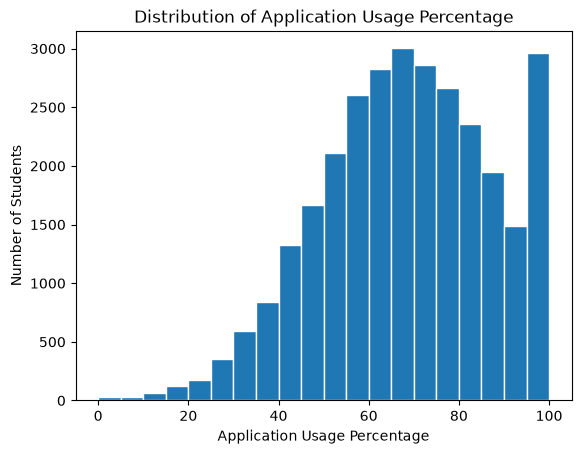

In [600]:
import matplotlib.pyplot as plt

plt.hist(
    df_etl_clean["App_Usage_Percentage"].dropna(),
    bins=20,
    edgecolor="white",
    linewidth=1,
)
plt.xlabel("Application Usage Percentage")
plt.ylabel("Number of Students")
plt.title("Distribution of Application Usage Percentage")
plt.show()

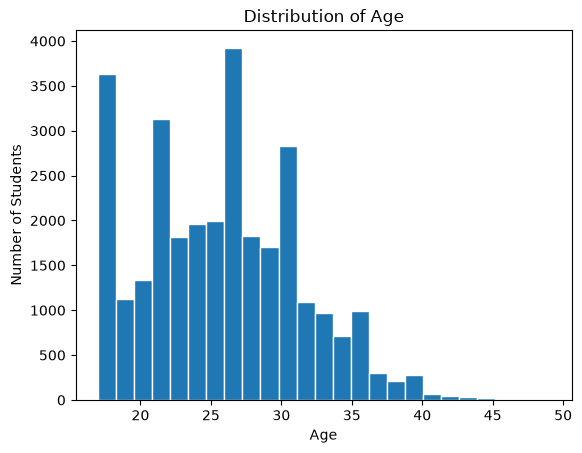

In [601]:
plt.hist(df_etl_clean["Age"].dropna(), bins=25, edgecolor="white", linewidth=1)
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.title("Distribution of Age")
plt.show()

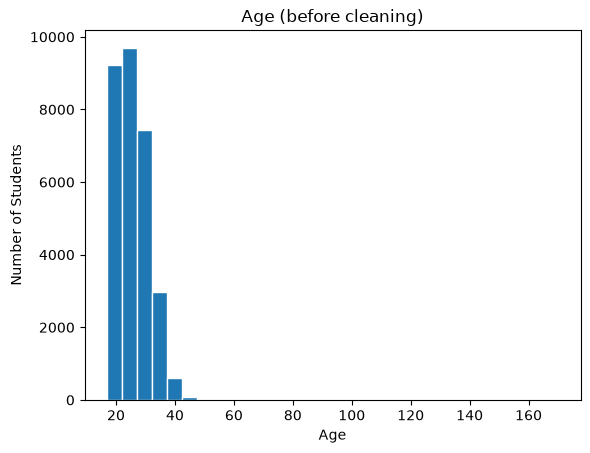

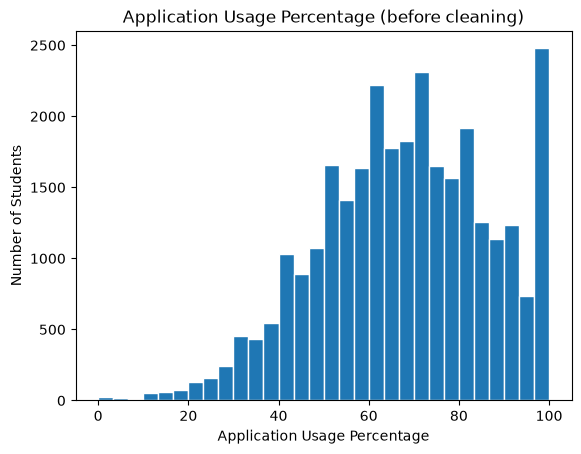

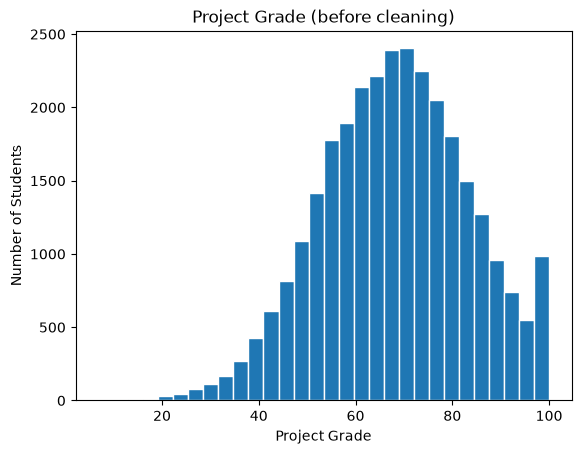

In [602]:
plt.hist(df_copy["Age"].dropna(), bins=30, edgecolor="white", linewidth=1)
plt.title("Age (before cleaning)")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.show()
plt.hist(
    df_copy["App_Usage_Percentage"].dropna(), bins=30, edgecolor="white", linewidth=1
)
plt.title("Application Usage Percentage (before cleaning)")
plt.xlabel("Application Usage Percentage")
plt.ylabel("Number of Students")
plt.show()
plt.hist(df_copy["Project_Grade"].dropna(), bins=30, edgecolor="white", linewidth=1)
plt.title("Project Grade (before cleaning)")
plt.xlabel("Project Grade")
plt.ylabel("Number of Students")
plt.show()

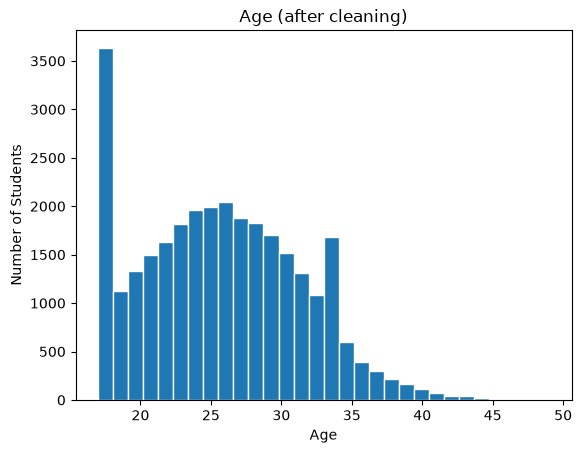

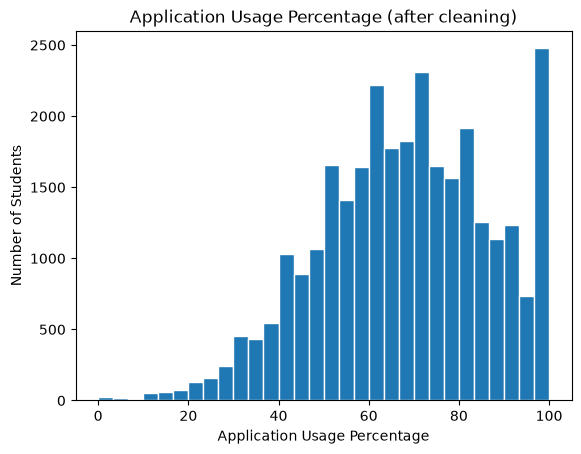

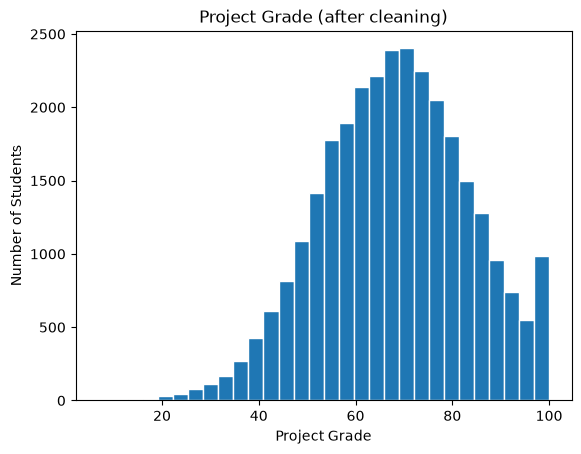

In [603]:
plt.hist(df_etl_clean["Age"].dropna(), bins=30, edgecolor="white", linewidth=1)
plt.title("Age (after cleaning)")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.show()
plt.hist(
    df_etl_clean["App_Usage_Percentage"].dropna(),
    bins=30,
    edgecolor="white",
    linewidth=1,
)
plt.title("Application Usage Percentage (after cleaning)")
plt.xlabel("Application Usage Percentage")
plt.ylabel("Number of Students")
plt.show()
plt.hist(
    df_etl_clean["Project_Grade"].dropna(), bins=30, edgecolor="white", linewidth=1
)
plt.title("Project Grade (after cleaning)")
plt.xlabel("Project Grade")
plt.ylabel("Number of Students")
plt.show()

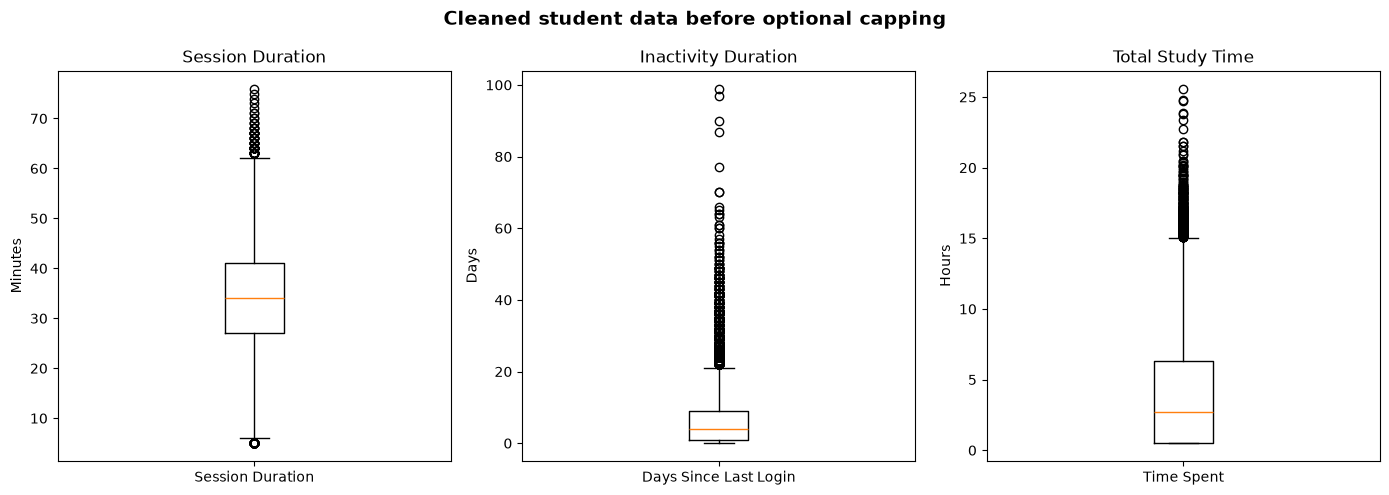

In [604]:
# Create subplots for the student dataset metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Plot 1: Average Session Duration
axes[0].boxplot(df_etl_clean["Average_Session_Duration_Min"].dropna(), tick_labels=["Session Duration"])
axes[0].set_title("Session Duration")
axes[0].set_ylabel("Minutes")

# Plot 2: Days Since Last Login
axes[1].boxplot(df_etl_clean["Days_Since_Last_Login"].dropna(), tick_labels=["Days Since Last Login"])
axes[1].set_title("Inactivity Duration")
axes[1].set_ylabel("Days")

# Plot 3: Total Time Spent
axes[2].boxplot(df_etl_clean["Time_Spent_Hours"].dropna(), tick_labels=["Time Spent"])
axes[2].set_title("Total Study Time")
axes[2].set_ylabel("Hours")

# Adjust formatting and show plots
plt.suptitle("Cleaned student data before optional capping", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

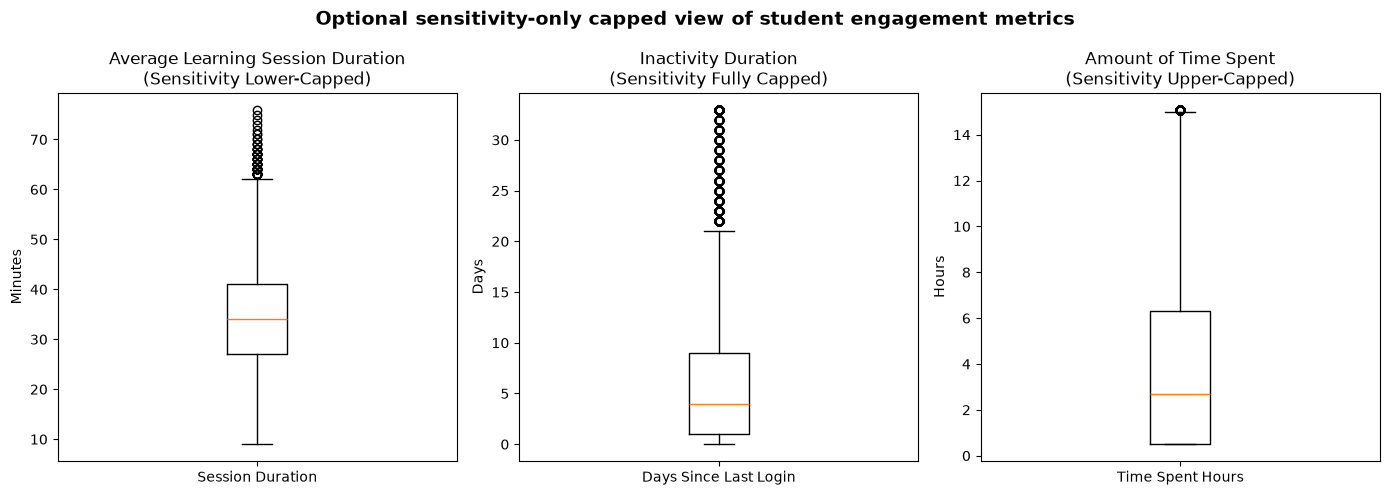

In [605]:
# Create a clean deep copy for sensitivity analysis
df_sensitivity = df_etl_clean.copy(deep=True)

# 1. Lower cap Average Learning Session Duration (removes accidental/instant login logs)
session_min_p01 = df_sensitivity["Average_Session_Duration_Min"].quantile(0.01)
df_sensitivity["Average_Session_Duration_Min_capped"] = df_sensitivity["Average_Session_Duration_Min"].clip(
    lower=session_min_p01
)

# 2. Fully cap Days Since Last Login (restrains extreme dormancy/inactive outliers)
dormancy_p01 = df_sensitivity["Days_Since_Last_Login"].quantile(0.01)
dormancy_p99 = df_sensitivity["Days_Since_Last_Login"].quantile(0.99)
df_sensitivity["Days_Since_Last_Login_capped"] = df_sensitivity["Days_Since_Last_Login"].clip(
    lower=dormancy_p01,
    upper=dormancy_p99
)

# 3. Upper cap Amount of Time Spent on Course (handles massive cramming/unrealistic hour spikes)
time_spent_p99 = df_sensitivity["Time_Spent_Hours"].quantile(0.99)
df_sensitivity["Time_Spent_Hours_capped"] = df_sensitivity["Time_Spent_Hours"].clip(
    upper=time_spent_p99
)

# Generate subplots mapping the template logic
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Plot 1: Average Session Duration
axes[0].boxplot(df_sensitivity["Average_Session_Duration_Min_capped"].dropna(), tick_labels=["Session Duration"])
axes[0].set_title("Average Learning Session Duration\n(Sensitivity Lower-Capped)")
axes[0].set_ylabel("Minutes")

# Plot 2: Days Since Last Login
axes[1].boxplot(df_sensitivity["Days_Since_Last_Login_capped"].dropna(), tick_labels=["Days Since Last Login"])
axes[1].set_title("Inactivity Duration\n(Sensitivity Fully Capped)")
axes[1].set_ylabel("Days")

# Plot 3: Time Spent Hours
axes[2].boxplot(df_sensitivity["Time_Spent_Hours_capped"].dropna(), tick_labels=["Time Spent Hours"])
axes[2].set_title("Amount of Time Spent\n(Sensitivity Upper-Capped)")
axes[2].set_ylabel("Hours")

# Global labels and execution layout
plt.suptitle("Optional sensitivity-only capped view of student engagement metrics", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


Course Completion Rate by Gender:
Gender
Female    0.500495
Male      0.485913
Other     0.474797
Name: is_completed, dtype: float64


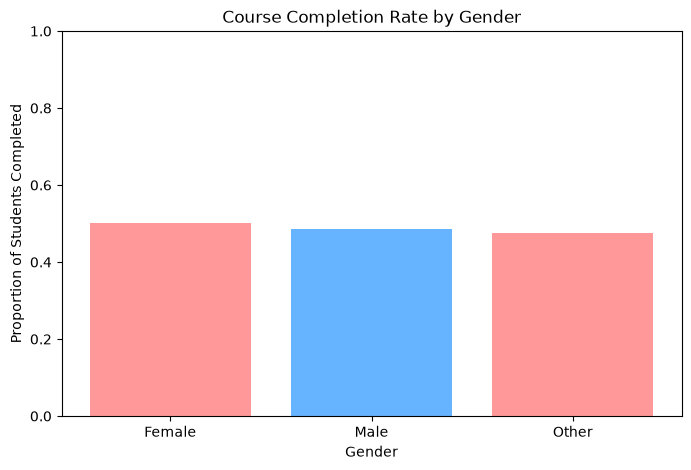

In [606]:
# Create a temporary copy to safely convert the categorical target variable
df_analysis = df_etl_clean.copy()

# Convert the string target 'Completed' into a binary 1/0 indicator variable
df_analysis["is_completed"] = (df_analysis["Completed"] == "Completed").astype(int)

# Group by Gender and calculate the average completion rate
rate = df_analysis.groupby("Gender", observed=False)["is_completed"].mean()
print("Course Completion Rate by Gender:")
print(rate)

# Plotting the aggregation results
plt.figure(figsize=(8, 5))
plt.bar(rate.index, rate.values, color=['#ff9999', '#66b3ff'])

# Setting explicit graph metadata
plt.xlabel("Gender")
plt.ylabel("Proportion of Students Completed")
plt.title("Course Completion Rate by Gender")
plt.ylim(0, 1.0)  # Caps the proportion axis up to 100% for clean readability
plt.show()


--- Correlation Matrix ---
                               Age  Course_Duration_Days  \
Age                           1.00                 -0.00   
Course_Duration_Days         -0.00                  1.00   
Average_Session_Duration_Min -0.00                  0.00   
Time_Spent_Hours             -0.00                  0.00   
Days_Since_Last_Login        -0.01                  0.01   
Quiz_Attempts                -0.01                  0.01   
Quiz_Score_Avg               -0.00                  0.01   

                              Average_Session_Duration_Min  Time_Spent_Hours  \
Age                                                  -0.00             -0.00   
Course_Duration_Days                                  0.00              0.00   
Average_Session_Duration_Min                          1.00              0.17   
Time_Spent_Hours                                      0.17              1.00   
Days_Since_Last_Login                                -0.03             -0.01   
Quiz_Attempt

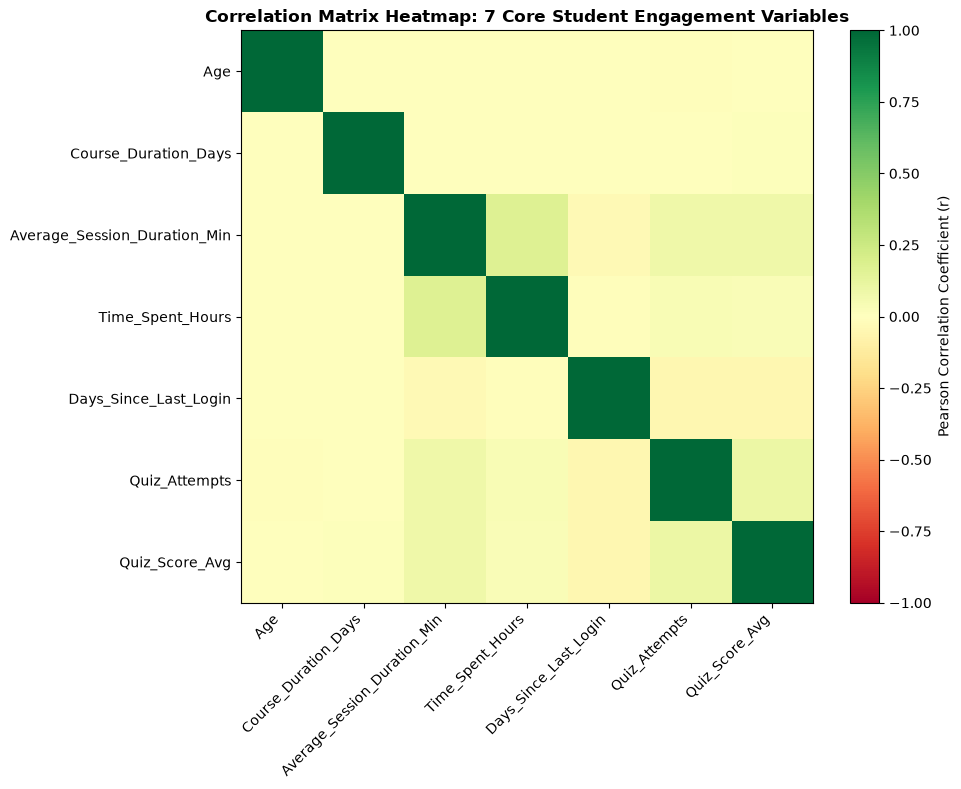

In [607]:
import numpy as np

# 1. Isolate 7 highly meaningful numerical columns from explicit dictionary schema
num_cols = [
    "Age",
    "Course_Duration_Days",
    "Average_Session_Duration_Min",
    "Time_Spent_Hours",
    "Days_Since_Last_Login",
    "Quiz_Attempts",
    "Quiz_Score_Avg"
]

# 2. Compute the Pearson correlation matrix
corr_matrix = df_etl_clean[num_cols].corr()
print("--- Correlation Matrix ---")
print(corr_matrix.round(2))
print("\n" + "="*50 + "\n")

# 3. Dynamically extract the strongest non-diagonal linear relationship
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
strongest_pair = upper_triangle.abs().stack().idxmax()

print("--- Strongest Linear Association Detected ---")
print(
    f"Strongest absolute correlation sits between: {strongest_pair[0]} and {strongest_pair[1]}"
)
print(f"Correlation Value: {round(corr_matrix.loc[strongest_pair[0], strongest_pair[1]], 2)}")
print("\n" + "="*50 + "\n")

# 4. Generate the structured heatmap visualization layout
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)

# Format axes parameters precisely using the custom feature slice array
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)

# Finalize rendering wrappers
plt.colorbar(label="Pearson Correlation Coefficient (r)")
plt.title(f"Correlation Matrix Heatmap: {len(num_cols)} Core Student Engagement Variables", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


Students enrolled per Course Subject Category:
Category
Business        3829
Design          2552
Marketing       3756
Math            3057
Programming    16801
Name: count, dtype: int64


Mean engagement profile per Subject Category:
             Login_Frequency  Average_Session_Duration_Min  \
Category                                                     
Business                 4.8                          33.8   
Design                   4.8                          33.8   
Marketing                4.7                          33.9   
Math                     4.8                          33.7   
Programming              4.8                          33.9   

             Video_Completion_Rate  Discussion_Participation  \
Category                                                       
Business                      62.2                       2.3   
Design                        62.1                       2.3   
Marketing                     62.7                       2.3   
Math      

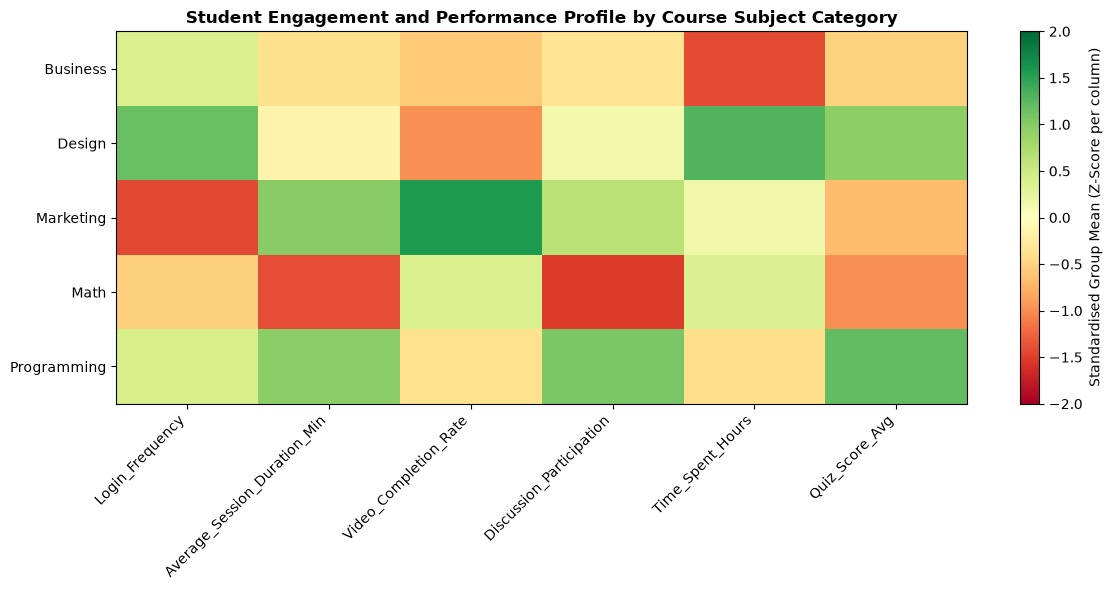

In [608]:
# 1. Isolate 6 foundational metrics to evaluate behavioral profile characteristics
behavior_cols = [
    "Login_Frequency",
    "Average_Session_Duration_Min",
    "Video_Completion_Rate",
    "Discussion_Participation",
    "Time_Spent_Hours",
    "Quiz_Score_Avg"
]

# 2. Extract distribution counts per course Subject Category
category_counts = df_etl_clean["Category"].value_counts().sort_index()
print("Students enrolled per Course Subject Category:")
print(category_counts)
print("\n" + "="*50 + "\n")

# 3. Aggregate column means grouped by Course Subject Category
profile = df_etl_clean.groupby("Category")[behavior_cols].mean()
print("Mean engagement profile per Subject Category:")
print(profile.round(1))
print("\n" + "="*50 + "\n")

# 4. Standardise columns (Z-score matrix conversion) so different scales 
# (Minutes vs Percentage Rates vs Hours) don't distort the color map intensity
profile_z = (profile - profile.mean()) / profile.std()

# 5. Extract group names directly as labels from index array values 
row_labels = list(profile_z.index)

# 6. Generate the standardised profile heatmap visualization layout
plt.figure(figsize=(12, 6))
plt.imshow(profile_z.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")

# Formatting layout axis metrics matching the structure template logic
plt.xticks(range(len(behavior_cols)), behavior_cols, rotation=45, ha="right")
plt.yticks(range(len(profile_z)), row_labels)

# Finalize rendering wrappers
plt.colorbar(label="Standardised Group Mean (Z-Score per column)")
plt.title("Student Engagement and Performance Profile by Course Subject Category", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


Percentage of missing entries captured per column:
Quiz_Score_Avg                  12.09
Device_Type                     11.86
Average_Session_Duration_Min    10.75
Satisfaction_Rating              6.20
dtype: float64


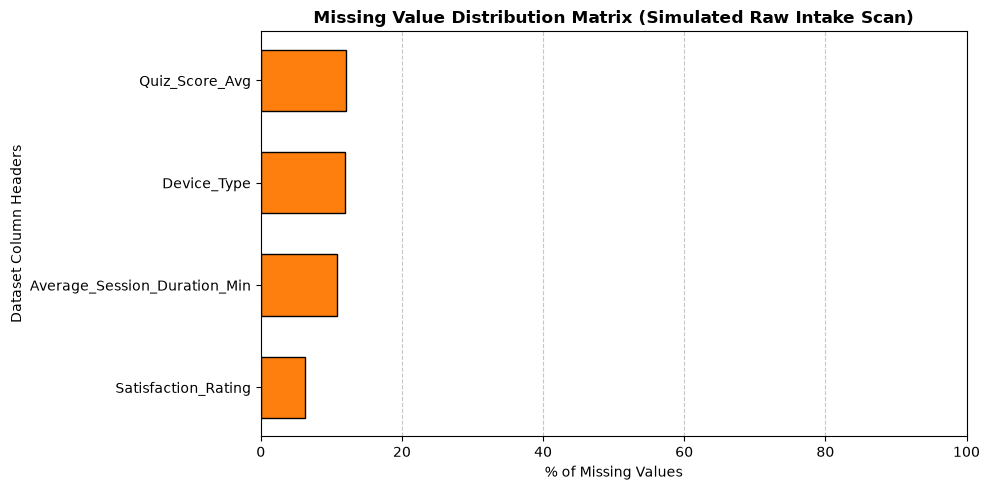

In [609]:
# Isolate a deep copy of the student dataset
df_copy = df_etl_clean.copy(deep=True)

for col in ["Average_Session_Duration_Min", "Quiz_Score_Avg", "Satisfaction_Rating", "Device_Type"]:
    # Randomly replace 5% to 15% of rows with null values
    df_copy.loc[df_copy.sample(frac=np.random.uniform(0.05, 0.15)).index, col] = np.nan

# Calculate the mean rate of missing fields and sort descending
miss = df_copy.isna().mean().sort_values(ascending=False)

# Isolate only fields containing missing instances and convert to a true percentage array
miss = miss[miss > 0] * 100

print("Percentage of missing entries captured per column:")
print(miss.round(2))

# Render horizontal bar distribution layout
plt.figure(figsize=(10, 5))
plt.barh(miss.index.astype(str), miss.values, color='#ff7f0e', edgecolor='black', height=0.6)

# Graph styling adjustments
plt.xlabel("% of Missing Values")
plt.ylabel("Dataset Column Headers")
plt.title("Missing Value Distribution Matrix (Simulated Raw Intake Scan)", fontsize=12, weight='bold')
plt.xlim(0, 100) # Sets scale boundaries up to 100% boundary limit
plt.gca().invert_yaxis() # Puts the column with highest missingness right at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Mean Time Spent (Hours) by Education Level:
Education_Level
HighSchool    3.936485
Diploma       3.799700
Bachelor      3.876674
Master        3.900215
PhD           4.093866
Name: Time_Spent_Hours, dtype: float64




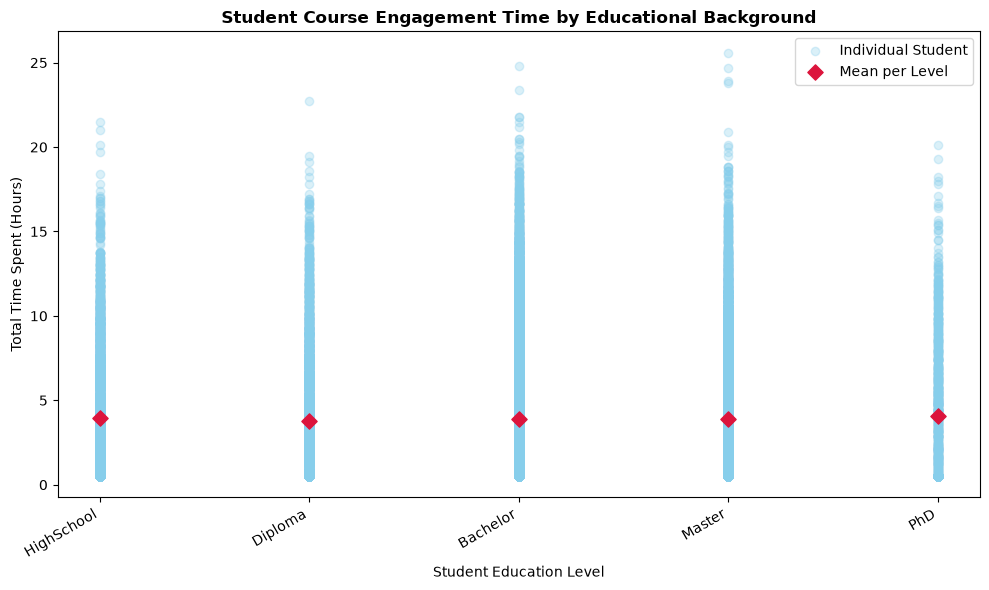

In [610]:

# 1. Define a logical educational order for the x-axis alignment
ordered_levels = ["HighSchool", "Diploma", "Bachelor", "Master", "PhD"]

# FIX: Corrected loop variable matching to ensure no NameError happens
order = [level for level in ordered_levels if level in df_etl_clean["Education_Level"].unique()]

# 2. Map categorical string tiers over to numerical coordinate index values
x_pos = df_etl_clean["Education_Level"].map({c: i for i, c in enumerate(order)})

# Set canvas dimensions
plt.figure(figsize=(10, 6))

# 3. Plot the raw background student distributions using alpha blending
plt.scatter(x_pos, df_etl_clean["Time_Spent_Hours"], alpha=0.3, color="skyblue", label="Individual Student")

# 4. Group by Education Level and calculate tracking averages
means = df_etl_clean.groupby("Education_Level")["Time_Spent_Hours"].mean()
print("Mean Time Spent (Hours) by Education Level:")
print(means.loc[order]) # Prints in the ordered logical structural layout
print("\n" + "="*50 + "\n")

# 5. Overlay the averaged metrics profile layer directly on top
plt.scatter(
    range(len(order)),
    [means[c] for c in order],
    color="crimson",
    marker="D",
    s=60, # Scale marker up slightly so it cuts through data density
    label="Mean per Level",
)

# 6. Apply explicit metric ticks and plot text wrappers
plt.xticks(range(len(order)), order, rotation=30, ha="right")
plt.xlabel("Student Education Level")
plt.ylabel("Total Time Spent (Hours)")
plt.title("Student Course Engagement Time by Educational Background", fontsize=12, weight='bold')
plt.legend()
plt.tight_layout()
plt.show()


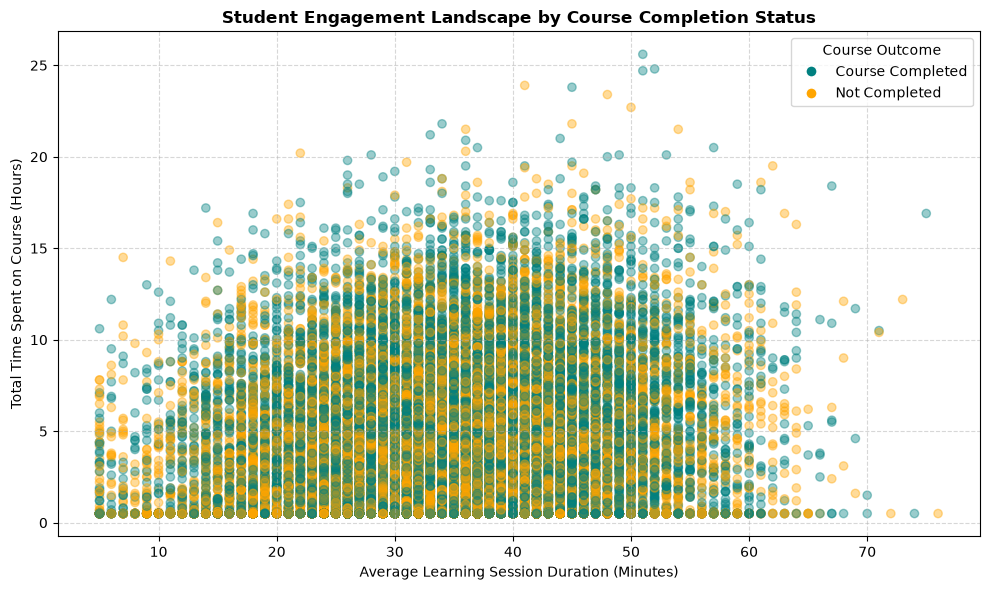

In [611]:
from matplotlib.lines import Line2D

# 1. Map the 'Completed' target variable string to distinct visual colours
# True Completion gets a distinct energetic colour, incomplete gets a neutral tone
colors = df_etl_clean["Completed"].map({"Completed": "teal", "Not Completed": "orange"})

# 2. Build the scatter plot distribution chart
plt.figure(figsize=(10, 6))
plt.scatter(
    df_etl_clean["Average_Session_Duration_Min"], 
    df_etl_clean["Time_Spent_Hours"], 
    c=colors, 
    alpha=0.4
)

# 3. Apply labels and structural text blocks matching the schema definitions
plt.xlabel("Average Learning Session Duration (Minutes)")
plt.ylabel("Total Time Spent on Course (Hours)")
plt.title("Student Engagement Landscape by Course Completion Status", fontsize=12, weight='bold')

# 4. Construct custom legend handles matching the structural blueprint logic
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="teal",
        markersize=8,
        label="Course Completed",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="orange",
        markersize=8,
        label="Not Completed",
    ),
]

# 5. Render wrappers and legends
plt.legend(handles=legend_handles, title="Course Outcome")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


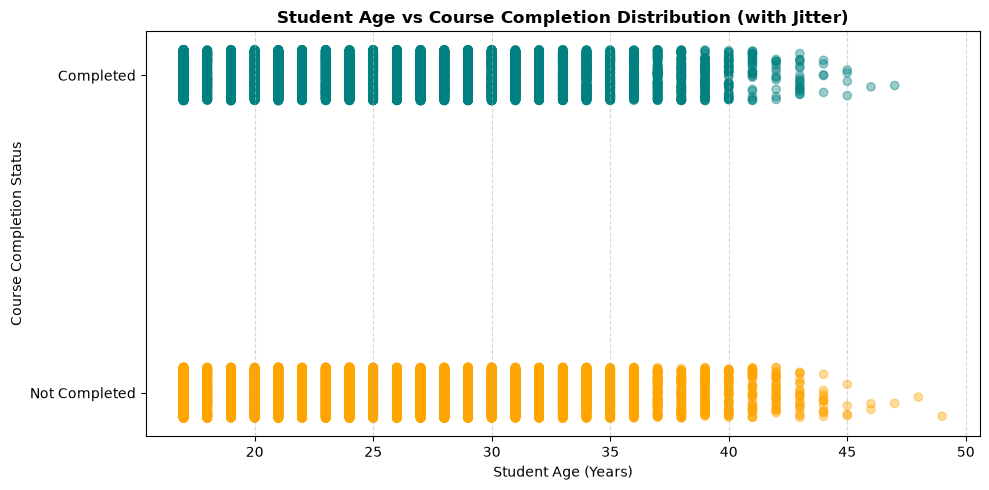

In [612]:
# 1. Map the 'Completed' target variable string to a binary indicator (1 or 0)
is_completed_binary = (df_etl_clean["Completed"] == "Completed").astype(int)

# 2. Add random uniform noise (jitter) to separate the overlapping points on the y-axis
jitter = is_completed_binary + np.random.uniform(-0.08, 0.08, len(df_etl_clean))

# 3. Map outcomes to matching colors
colors = df_etl_clean["Completed"].map({"Completed": "teal", "Not Completed": "orange"})

# 4. Create the jittered scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(df_etl_clean["Age"], jitter, c=colors, alpha=0.4)

# 5. Format axes, custom text labels, and graph metadata
plt.yticks([0, 1], ["Not Completed", "Completed"])
plt.xlabel("Student Age (Years)")
plt.ylabel("Course Completion Status")
plt.title("Student Age vs Course Completion Distribution (with Jitter)", fontsize=12, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


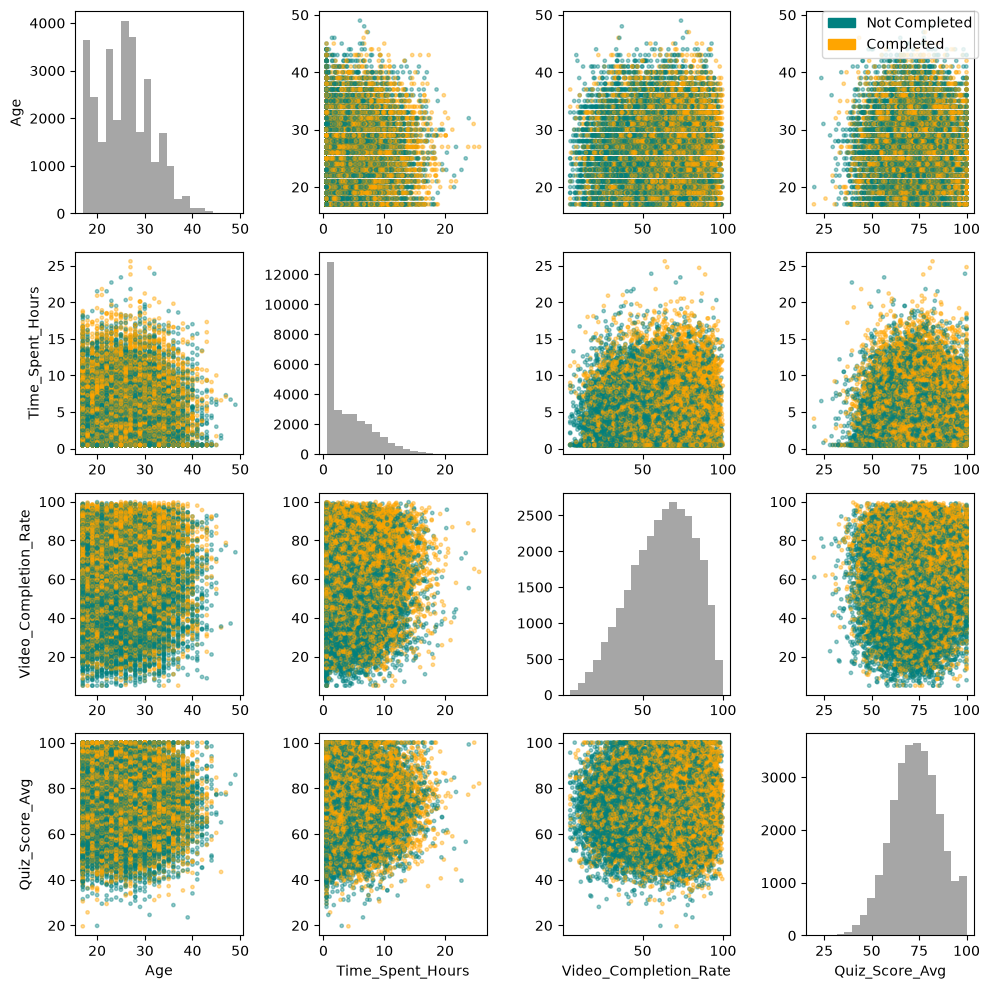

In [613]:
from matplotlib.patches import Patch

# 1. Create a safe color mapping column handling both Boolean and Numeric binary formats
df_etl_clean["color_map"] = df_etl_clean["Completed_Status"].map(
    {True: "orange", 1: "orange", False: "teal", 0: "teal"}
)

# 2. Define the 4 numerical student columns to cross-analyze
cols = ["Age", "Time_Spent_Hours", "Video_Completion_Rate", "Quiz_Score_Avg"]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        ax = axes[i, j]

        if i == j:
            # Diagonal: Distribution histogram of the variable
            ax.hist(df_etl_clean[c1].dropna(), bins=20, color="gray", alpha=0.7)
        else:
            # Off-diagonal: Scatter plot dropping missing values dynamically to maintain length alignment
            temp_df = df_etl_clean[[c2, c1, "color_map"]].dropna()
            ax.scatter(
                temp_df[c2],
                temp_df[c1],
                s=6,
                alpha=0.4,
                c=temp_df["color_map"],
            )

        # Set cleanly positioned boundary labels
        if i == 3:
            ax.set_xlabel(c2)
        if j == 0:
            ax.set_ylabel(c1)

plt.tight_layout()

# 3. Generate the custom course completion legend
fig.legend(
    handles=[
        Patch(color="teal", label="Not Completed"),
        Patch(color="orange", label="Completed"),
    ],
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
)

plt.show()


In [614]:
from scipy import stats

# Clean missing values first to prevent t-test calculation failures
df_clean_stats = df_etl_clean.dropna(
    subset=["Quiz_Score_Avg", "Completed_Status"]
)

# Separate the groups using your newly created boolean column
completed_group = df_clean_stats.loc[
    df_clean_stats["Completed_Status"] == True, "Quiz_Score_Avg"
]
incomplete_group = df_clean_stats.loc[
    df_clean_stats["Completed_Status"] == False, "Quiz_Score_Avg"
]

# Run Welch's t-test (equal_var=False handles groups with different sizes and variances)
t, p = stats.ttest_ind(completed_group, incomplete_group, equal_var=False)

print("Mean Quiz Score (Completed):", completed_group.mean())
print("Mean Quiz Score (Incomplete):", incomplete_group.mean())

print(f"t = {t:.2f}, p = {p:.4f}")

if p < 0.05:
    print(
        "Reject H0: The mean quiz scores between the two groups differ significantly."
    )
else:
    print(
        "Fail to reject H0: No significant difference in mean quiz scores was detected."
    )


Mean Quiz Score (Completed): 74.26868618567855
Mean Quiz Score (Incomplete): 72.14159542285941
t = 14.69, p = 0.0000
Reject H0: The mean quiz scores between the two groups differ significantly.


In [615]:
import pandas as pd
from scipy import stats

# 1. Create the contingency table cross-tabulating Gender and Course Completion
table = pd.crosstab(df_etl_clean["Gender"], df_etl_clean["Completed_Status"])
print("--- CONTINGENCY TABLE ---")
print(table)
print("-" * 25)

# 2. Run the Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"chi2 = {chi2:.2f}, p = {p:.6f}")

if p < 0.05:
    print(
        "Reject H0: Gender and course completion are significantly associated in this sample."
    )
else:
    print(
        "Fail to reject H0: No significant association between gender and course completion was detected."
    )


--- CONTINGENCY TABLE ---
Completed_Status  False  True 
Gender                        
Female             7566   7581
Male               7317   6916
Other               323    292
-------------------------
chi2 = 7.08, p = 0.029023
Reject H0: Gender and course completion are significantly associated in this sample.
